# 1. ANN & DNN

##1. OR 게이트 학습 및 시각화 (ANN)

In [ ]:
# 라이브러리 import
import torch
import torch.nn as nn
import pandas as pd
import numpy as np

# x1, x2 좌표 입력
input = pd.DataFrame([(0, 0), (0, 1), (1, 0), (1, 1)], columns=['x1', 'x2'])
input

,x1,x2
0,0,0
1,0,1
2,1,0
3,1,1


In [ ]:
# 규칙에 따라 y 값 계산
or_gate_y = []
for i in range(len(input)):
  if input.loc[i, 'x1'] + input.loc[i, 'x2'] >= 1:
    or_gate_y.append(1)
  else:
    or_gate_y.append(0)

or_gate_y

[0, 1, 1, 1]

In [ ]:
#or_gate 완성
or_gate = input.assign(y=or_gate_y)
or_gate

,x1,x2,y
0,0,0,0
1,0,1,1
2,1,0,1
3,1,1,1


In [ ]:
# x1+x2=0.5 직선을 기준으로 분류
def seperate(x1, x2):
  if x1 + x2 > 0.5:
    return 1
  else:
    return 0

for i in range(len(input)):
  print(seperate(input.loc[i, 'x1'], input.loc[i, 'x2']))

0
1
1
1


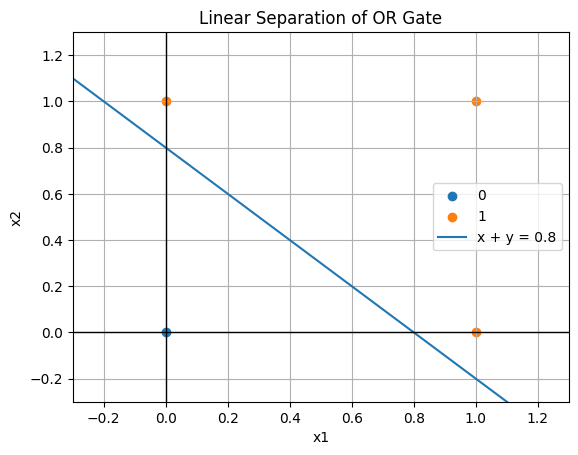

In [ ]:
#시각화
import matplotlib.pyplot as plt
fig, ax = plt.subplots()

#데이터 찍기
ax.scatter(or_gate[or_gate['y']==0]['x1'], or_gate[or_gate['y']==0]['x2'], label='0')
ax.scatter(or_gate[or_gate['y']==1]['x1'], or_gate[or_gate['y']==1]['x2'], label='1')

#직선 그리기
xs = [-2, 2]
ys = [0.8 - xs[0], 0.8 - xs[1]]
ax.plot(xs, ys, label='x + y = 0.8')

#좌표 평면 그리기
ax.grid(True)
ax.axhline(0, color='black', linewidth=1)
ax.axvline(0, color='black', linewidth=1)

# 배경 좌표 고정 및 레이블 기입
ax.set_xlabel('x1')
ax.set_ylabel('x2')

ax.set_xlim(-0.3, 1.3)
ax.set_ylim(-0.3, 1.3)

ax.set_title('Linear Separation of OR Gate')
ax.legend()
plt.show()


##2. XOR 게이트 학습 시도 및 한계 시각화 (ANN)

In [ ]:
#논리 곱에 따라 y 값 계산
xor_gate_y = []
for i in range(len(input)):
  if input.loc[i, 'x1'] - input.loc[i, 'x2'] != 0:
    xor_gate_y.append(1)
  else:
    xor_gate_y.append(0)

xor_gate_y

[0, 1, 1, 0]

In [ ]:
#xor_gate 완성
xor_gate = input.assign(y=xor_gate_y)
xor_gate

,x1,x2,y
0,0,0,0
1,0,1,1
2,1,0,1
3,1,1,0


In [ ]:
#데이터 재구성
X = torch.tensor(xor_gate[['x1', 'x2']].values, dtype=torch.float32)
y = torch.tensor(xor_gate['y'].values, dtype=torch.float32).view(-1, 1)

#모델 구성(파이토치)
model_sl = nn.Sequential(
    nn.Linear(2, 1),
    nn.Sigmoid()
)

criterion = nn.BCELoss()
optimizer = torch.optim.SGD(model_sl.parameters(), lr=0.01)

In [ ]:
#모델 학습
epochs = 1000
for epoch in range(epochs):
    optimizer.zero_grad()
    preds = model_sl(X)
    loss = criterion(preds, y)
    loss.backward()
    optimizer.step()

#예측값
with torch.no_grad():
    output = model_sl(X)
    print("Predictions:", (output.numpy() > 0.5).astype(int).flatten())

Predictions: [1 0 1 0]


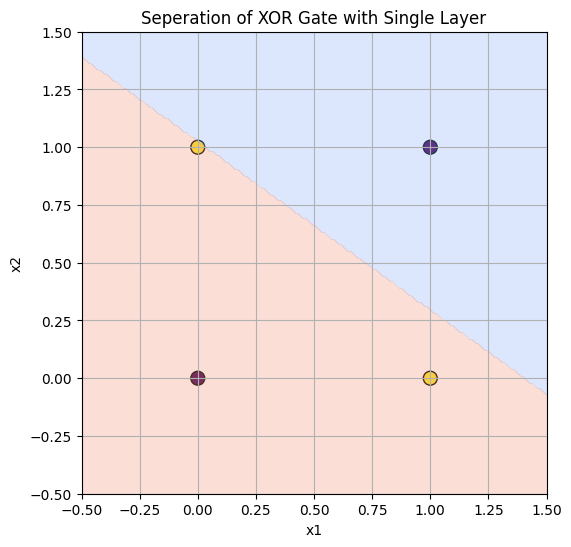

In [ ]:
# 플롯 그리기
grid_x = np.linspace(-0.5, 1.5, 200)
grid_y = np.linspace(-0.5, 1.5, 200)
xx, yy = np.meshgrid(grid_x, grid_y)

#그래프 좌표를 펼쳐 예측 준비
grid_tensor = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

#플롯에 모델을 나타내기 위한 과정
#with torch.no_grad: 예측 과정에서는 자동미분이 필요 없으므로 더 빠른 학습을 위해 자동 미분을 끔.
#분류 모델의 경계값(예측)을 구한 뒤, 그래프에 맞게 reshape.
with torch.no_grad():
    grid_pred = model_sl(grid_tensor).reshape(xx.shape)

plt.figure(figsize=(6,6))
plt.title('Seperation of XOR Gate with Single Layer')
plt.scatter(xor_gate['x1'], xor_gate['x2'], c=xor_gate['y'], s=100, edgecolors="k")
plt.contourf(xx, yy, grid_pred.numpy() > 0.5, alpha=0.3, cmap='coolwarm')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid(True)
plt.show()

## 3. XOR 게이트 학습 및 시각화 (DNN)

In [ ]:
#모델 구성(파이토치)
model_dl = nn.Sequential(
    nn.Linear(2, 4),
    nn.Tanh(),
    nn.Linear(4, 2),
    nn.Tanh(),
    nn.Linear(2, 1),
    nn.Sigmoid()

)

criterion = nn.BCELoss()
optimizer = torch.optim.SGD(model_dl.parameters(), lr=0.01)

In [ ]:
#모델 학습
epochs = 10000
for epoch in range(epochs):
    optimizer.zero_grad()
    preds = model_dl(X)
    loss = criterion(preds, y)
    loss.backward()
    optimizer.step()

#예측값
with torch.no_grad():
    output = model_dl(X)
    print("Predictions:", (output.numpy() > 0.5).astype(int).flatten())

Predictions: [0 1 1 0]


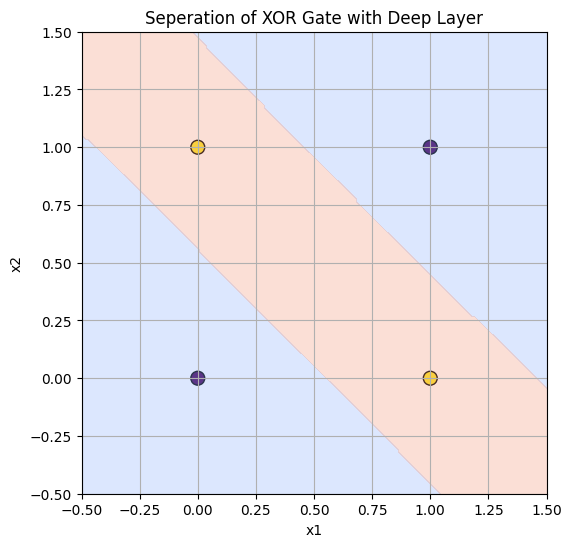

In [ ]:
# 플롯 그리기
grid_x = np.linspace(-0.5, 1.5, 200)
grid_y = np.linspace(-0.5, 1.5, 200)
xx, yy = np.meshgrid(grid_x, grid_y)
grid_tensor = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

#플롯에 모델을 나타내기 위한 과정
with torch.no_grad():
    grid_pred = model_dl(grid_tensor).reshape(xx.shape)

plt.figure(figsize=(6,6))
plt.title('Seperation of XOR Gate with Deep Layers')
plt.scatter(xor_gate['x1'], xor_gate['x2'], c=xor_gate['y'], s=100, edgecolors="k")
plt.contourf(xx, yy, grid_pred.numpy() > 0.5, alpha=0.3, cmap='coolwarm')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid(True)
plt.show()

**보고서** <p> &nbsp;
1번 선형 분리에서는 레이블이 0인 데이터와 1인 데이터를 구분할 수 있는 직선을 임의로 설정했습니다. <p> &nbsp;
2번 중 단일층으로 이뤄진 모델을 사용하여 XOR 데이터를 구분하는 문제에서는 멘토멘티 스터에서 공부하는 파이토치를 이용하여 모델을 구성했습니다. Sequential을 통해 입력값이 2이고 출력값이 1인 모델과 이진 분류를 위한 활성화 함수인 시그모이드 함수를 사용했습니다. 마찬가지로 손실함수 또한 이진 분류를 위해 Binary Cross Entropy 함수를 사용했습니다.데이터 수가 적다보니 Optimizer로 Stochastic Gradient Backpropagation을 선택했습니다. 하지만 단일층을 사용하다 보니 잘못된 결과가 나옴을 볼 수 있습니다. 선형성이 지닌 한계라고 볼 수 있습니다.
<p> &nbsp;
2번 중 DNN 즉 2개 이상의 층을 사용한 모델에서는 나머지 설정이 단일층과 모두 같으나, 2&times;4, 4&times;2의 은닉층, 2&times;1의 출력층으로 구성했습니다. 또한 선형적으로 분리가 불가능하다는 것을 알고 있기에 tanh를 은닉층의 활성화 함수로 택했습니다. 이후 예측값과 그래프에서 올바르게 분류된 것을 확인할 수 있었습니다.

#2. CNN

In [ ]:
# 그럼 첫번째 레슨 : 라이브러리 불러오기

#필요한 딥러닝 관련 라이브러리를 불러옵니다.

import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

In [ ]:
# 🗂️ Step 2: 데이터 불러오기

#CIFAR-10 데이터셋을 불러오고, 학습용/테스트용으로 분리합니다.

(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


## 과제1. 데이터의 구조를 살펴보세요. 사이즈는?

In [ ]:
# 여기에서 확인해 보세요.

print('train_images shape:', train_images.shape)
print('train_labels shape:', train_labels.shape)
print('test_images shape:', test_images.shape)
print('test_labels shape:', test_labels.shape)

train_images shape: (50000, 32, 32, 3)
train_labels shape: (50000, 1)
test_images shape: (10000, 32, 32, 3)
test_labels shape: (10000, 1)


In [ ]:
# 🏷️ Step 3: 클래스 이름 정의

#CIFAR-10의 라벨은 숫자로 되어 있으므로, 사람이 이해할 수 있도록 이름을 부여합니다.
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

## 과제2. 아래 코드의 빈칸을 채워 CNN 모델을 완성해보세요.
#### layer나 패딩 혹은 drop out, batch normalization을 추가해 가며 모델의 정확도 변화를 보는 것도 좋습니다.

In [ ]:
# 🧱 Step 4: CNN 모델 구성
# Convolution → MaxPooling → Flatten → Dense 구조로 CNN을 설계합니다.
# 아래의 빈칸 (___)을 채워 모델을 완성해보세요.

model = models.Sequential()

# 첫 번째 합성곱 레이어
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))  # TODO: 커널 개수 설정

# 첫 번째 풀링 레이어
model.add(layers.MaxPooling2D((2, 2)))  # TODO: 풀링 크기 설정

# 두 번째 합성곱 레이어
model.add(layers.Conv2D(64, (3, 3), activation='relu'))  # TODO: 커널 크기 설정

# 두 번째 풀링 레이어
model.add(layers.MaxPooling2D((2, 2)))

# 세 번째 합성곱 레이어
model.add(layers.Conv2D(128, (3, 3), activation='relu'))  # TODO: 커널 개수 설정

# Flatten + Fully Connected Layer
model.add(layers.Flatten())
model.add(layers.Dense(128))  # TODO: 은닉층 유닛 수 설정
model.add(layers.Dense(10))  # 출력층: CIFAR-10은 클래스가 10개

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## 자신이 채운 코드를 기반으로 각 레이어별 Feature Map 크기를 계산해 보세요.
(padding은 디폴트로 없습니다.)

Answer: <br>
입력 데이터 : (32, 32, 3) <br>
첫 번째 합성곱 이후 피쳐 맵 : (30, 30, 32) <br>
첫 번째 풀링 이후 피쳐 맵 : (15, 15, 32) <br>
두 번째 합성곱 이후 피쳐 맵 : (13, 13, 64) <br>
두 번째 풀링 이후 피쳐 맵 : (6, 6, 64) <br>
Flatten 이후 : (2304) <br>
첫 번째 Dense 이후 : (128) <br>
두 번째 Dense 이후 : (10)


In [ ]:
# ⚙️ Step 5: 모델 컴파일

#모델을 학습할 수 있도록 컴파일합니다. 손실 함수, 최적화 방법, 평가지표를 설정합니다.

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.1869 - loss: 4.7426 - val_accuracy: 0.4112 - val_loss: 1.5791
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.4469 - loss: 1.5257 - val_accuracy: 0.4995 - val_loss: 1.3781
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.5266 - loss: 1.3296 - val_accuracy: 0.5435 - val_loss: 1.3117
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5774 - loss: 1.2048 - val_accuracy: 0.5999 - val_loss: 1.1448
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.6204 - loss: 1.0845 - val_accuracy: 0.5959 - val_loss: 1.1650
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.6499 - loss: 1.0019 - val_accuracy: 0.6272 - val_loss: 1.0870
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6855 - loss: 0.9031 - val_accuracy: 0.6344 - val_loss: 1.1127
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7007 - loss: 0.86

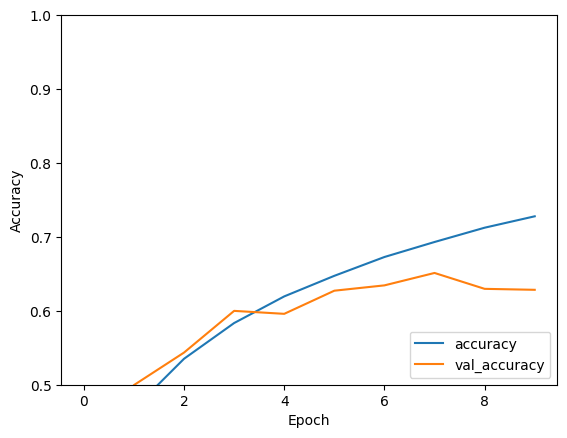

In [ ]:
# 🔥 Step 6: 모델 학습 및 성능 평가

history = model.fit(train_images, train_labels, epochs=10,
                    validation_data=(test_images, test_labels))
#모델 성능 평가
plt.plot(history.history['accuracy'],label='accuracy')
plt.plot(history.history['val_accuracy'],label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(test_images,
                                     test_labels,
                                     verbose=2)
print('Test Accuracy is',test_acc)

313/313 - 1s - 2ms/step - accuracy: 0.6284 - loss: 1.1788
Test Accuracy is 0.6284000277519226


## 과제3. 직접사용해 보기. 이미지를 로드하고 cifar-10의 사이즈로 리사이즈

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

# 새 이미지를 로드하고 모델 예측 수행
def predict_new_image(image_path, model, class_names):
    # 이미지 로드 및 전처리
    img = image.load_img(image_path, target_size=(32, 32))  # CIFAR-10 크기로 리사이즈 빈칸채우기
    img_array = image.img_to_array(img)  # 이미지를 배열로 변환
    img_array = np.expand_dims(img_array, axis=0)  # 배치를 위해 차원 추가
    img_array = img_array / 255.0  # 정규화

    # 예측 수행
    predictions = model.predict(img_array)
    predicted_class = np.argmax(predictions)  # 가장 높은 확률의 클래스 인덱스
    class_name = class_names[predicted_class]  # 클래스 이름

    # 결과 출력
    plt.imshow(img)
    plt.title(f"Predicted: {class_name}")
    plt.axis('off')
    plt.show()

# 사용 예시
#image_path =  # 예측할 이미지의 경로 절대경로를 입력하면 됩니다. 뭔가 자신의 얼굴사진을 넣어보면 재미있는일이...
# predict_new_image(image_path, model, class_names)


## 왜 255.0으로 나누었을까요? 이미지 전처리에 대한 지식이니 조사해보세요.

Answer: 모델 학습에 있어서 데이터 값이 0&#126;1 사이에 있는 것이 gradient 계산과 학습 안정성 측면에서 유리하다고 합니다.<br>그런데 이미지 데이터의 픽셀 값 범위는 0~255이므로 255로 나눠 정규화 합니다.



## 과제4. CNN의 inductive bias에 대해서 조사를 해보고 생각해 봅시다.
### CNN은 왜 이미지 처리에 좋을까요? 이미지 말고도 CNN을 잘 쓸 수 있는데는 어디일까요?

Answer: CNN은 픽셀들의 위치 정보를 유지한 상태에서 학습합니다. 따라서 주변 정보가 중요한 이미지에 유리합니다. 또한 한 이미지는 같은 패턴이 잘 등장하는데 하나의 필터로 전체 이미지를 다 돌면서 특성을 추출하기 때문에도 이미지에 유리합니다. 즉, 주변 정보가 중요하고 비슷한 패턴이 위치만 다르게 등장하는 데이터에 유리하므로 텍스트 중에 키워드를 통해 스팸 메일을 필터링 하거나 감성 분석을 통해 문장을 분류할 때에도 유리하다고 합니다.